# Deep Learning with Keras – Credit Card Customer Churn Prediction



### Business Scenario
A bank wants to predict whether a customer will leave the bank.

- `Exited = 0` → Customer stayed
- `Exited = 1` → Customer left (churned)

### Complete Process
**Business Problem → Load Data → Understand Data → Clean Data → Encode Features → Train/Test Split → Scale Features → Build Neural Network → Compile → Train → Backpropagation → Evaluate → Improve → Interpret Results**

# 1. Import Required Libraries

### Why each library?
- **NumPy (`np`)**: numerical arrays and mathematical operations.
- **Pandas (`pd`)**: loading and manipulating tabular data.
- **Matplotlib**: visualizing training curves and data.
- **Scikit-learn**: preprocessing, splitting data and evaluation.
- **TensorFlow/Keras**: building and training neural networks.

Keras is a high-level API inside TensorFlow that makes neural network development easier.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 2. Load the Dataset

The uploaded notebook uses Kaggle's `Churn_Modelling.csv`.

If you run this notebook locally, change `DATA_PATH` to your CSV location.

Example:
```python
DATA_PATH = "Churn_Modelling.csv"
```

The dataset contains customer information such as:
- Credit score
- Geography
- Gender
- Age
- Tenure
- Balance
- Number of products
- Estimated salary
- Exited (target)

In [ ]:
# DATA_PATH = "/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv"
# # For local Jupyter/VS Code, change the path above if required.
# # 
# df = pd.read_csv(DATA_PATH)
# display(df.head())

In [2]:
import pandas as pd

DATA_PATH = r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\1.customer-churn-prediction-using-ann\Churn_Modelling.csv"

df = pd.read_csv(DATA_PATH)

display(df.head())

print("Shape:", df.shape)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Shape: (10000, 14)


# 3. Understand Dataset Structure

### `df.shape`
Returns:
`(rows, columns)`

### `df.info()`
Shows:
- column names
- data types
- non-null values
- memory usage

This is important before modeling because neural networks require numeric input and missing values must be handled.

In [3]:
print("Dataset shape:", df.shape)
df.info()

print("\nMissing values:")
display(df.isnull().sum())

Dataset shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing values:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# 4. Check Duplicate Records

Duplicate rows can cause the model to learn repeated observations and may bias results.

If duplicates exist, investigate whether they are truly duplicate customers or legitimate repeated records.

In [4]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


# 5. Understand the Target Variable – `Exited`

This is a **binary classification** problem.

- `0` = customer did not churn
- `1` = customer churned

We also inspect the class balance. If churned customers are much fewer than existing customers, accuracy alone may be misleading.

Counts:
Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


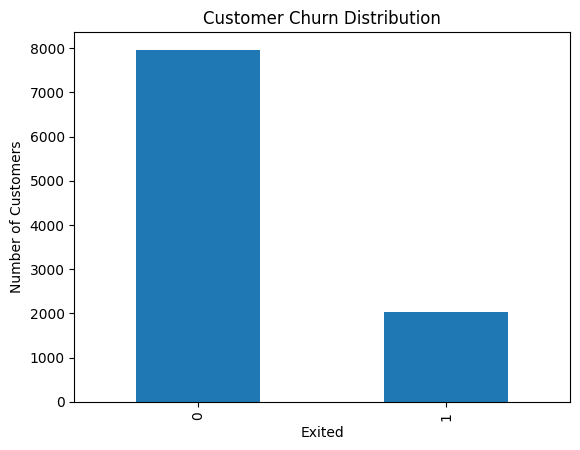

In [5]:
target_counts = df['Exited'].value_counts()
target_percent = df['Exited'].value_counts(normalize=True) * 100

print("Counts:")
print(target_counts)

print("\nPercentage:")
print(target_percent.round(2))

target_counts.plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

# 6. Explore Important Categorical Features

The uploaded notebook checks:
- Geography
- Gender

This helps us understand customer composition and prepares us for encoding categorical data.

In [6]:
print("Geography distribution:")
print(df['Geography'].value_counts())

print("\nGender distribution:")
print(df['Gender'].value_counts())

Geography distribution:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender distribution:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


# 7. Scenario-Based Exploration

Before building a neural network, it is useful to ask business questions:

- Which age groups churn more?
- Does geography affect churn?
- Do customers with higher balances leave more?

These simple comparisons improve understanding of the dataset and help connect ML with the business problem.

In [7]:
print("Average values grouped by churn:")
display(df.groupby('Exited')[['Age', 'Balance', 'CreditScore',
                              'Tenure', 'EstimatedSalary']].mean().round(2))

print("\nChurn rate by Geography:")
display(pd.crosstab(df['Geography'], df['Exited'], normalize='index').round(3))

print("\nChurn rate by Gender:")
display(pd.crosstab(df['Gender'], df['Exited'], normalize='index').round(3))

Average values grouped by churn:


,Age,Balance,CreditScore,Tenure,EstimatedSalary
Exited,,,,,
0,37.41,72745.30,651.85,5.03,99738.39
1,44.84,91108.54,645.35,4.93,101465.68



Churn rate by Geography:


Exited,0,1
Geography,,
France,0.838,0.162
Germany,0.676,0.324
Spain,0.833,0.167



Churn rate by Gender:


Exited,0,1
Gender,,
Female,0.749,0.251
Male,0.835,0.165


# 8. Remove Identifier Columns

The original notebook removes:
- `RowNumber`
- `CustomerId`
- `Surname`

### Why?
These columns identify a customer but usually do not represent meaningful behavioral patterns.

Using identifiers can cause the model to memorize records rather than learn general relationships.

This is an important concept:

**Useful predictive feature ≠ Unique identifier**

In [8]:
df_model = df.copy()

df_model.drop(
    columns=['RowNumber', 'CustomerId', 'Surname'],
    inplace=True
)

display(df_model.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# 9. Encode Categorical Variables

Neural networks need numeric input.

We use **One-Hot Encoding** for:
- Geography
- Gender

### `drop_first=True`
Removes one redundant category from each encoded group.

For example, if Geography has France, Germany and Spain, two binary columns are sufficient to represent all three categories.

In [9]:
df_encoded = pd.get_dummies(
    df_model,
    columns=['Geography', 'Gender'],
    dtype=int,
    drop_first=True
)

display(df_encoded.head())
print("Encoded dataset shape:", df_encoded.shape)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


Encoded dataset shape: (10000, 12)


# 10. Separate Features (X) and Target (y)

### `X`
Input features used by the neural network.

### `y`
Actual answer the model should learn to predict.

In this scenario:

**Customer features → Neural Network → Probability of Churn**

In [10]:
X = df_encoded.drop(columns=['Exited'])
y = df_encoded['Exited']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of input features:", X.shape[1])

X shape: (10000, 11)
y shape: (10000,)
Number of input features: 11


# 11. Train/Test Split

We divide the data into:

### Training Data
Used to learn weights and biases.

### Test Data
Used only after training to evaluate how well the model generalizes to unseen customers.

`stratify=y` keeps churn proportions similar in both sets.

`random_state=42` makes the split reproducible.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: (8000, 11)
Testing shape : (2000, 11)


# 12. Feature Scaling – StandardScaler

Neural networks train using gradients. Features with very different scales can make optimization difficult.

Examples:
- Age: approximately tens
- Balance: potentially hundreds of thousands

`StandardScaler` transforms features approximately around:

**Mean = 0 and Standard Deviation = 1**

### Important Data Leakage Rule
Fit the scaler only on training data:

```python
scaler.fit_transform(X_train)
scaler.transform(X_test)
```

Do **not** fit again on test data.

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

print("\nFirst scaled training row:")
print(X_train_scaled[0])

Scaled training data shape: (8000, 11)
Scaled test data shape: (2000, 11)

First scaled training row:
[ 1.058568    1.71508648  0.68472287 -1.22605881 -0.91025649  0.64104192
 -1.030206    1.04208392 -0.57831252 -0.57773517  0.90750738]


# 13. Import Neural Network Components

### `Sequential`
Used when layers are stacked one after another.

### `Dense`
A fully connected layer.

Each neuron calculates:

**z = Σ(w × x) + b**

Then applies an activation function:

**a = f(z)**

Where:
- `x` = input
- `w` = weight
- `b` = bias
- `z` = weighted sum
- `f` = activation function
- `a` = output

# 14. Build the Neural Network

Architecture:

**Input → Dense(11, ReLU) → Dense(11, ReLU) → Dense(1, Sigmoid)**

### ReLU
`max(0, x)`

Commonly used in hidden layers because it is computationally simple and helps with gradient flow.

### Sigmoid
Produces values between `0` and `1`.

For example:
- `0.08` → low probability of churn
- `0.87` → high probability of churn

The number of input features is calculated dynamically using `X_train_scaled.shape[1]`.

In [13]:
n_features = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    Dense(11, activation='relu', name='hidden_layer_1'),
    Dense(11, activation='relu', name='hidden_layer_2'),
    Dense(1, activation='sigmoid', name='output_layer')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

# 15. Understanding Model Summary and Parameters

A Dense layer learns:
- **Weights**
- **Biases**

For a Dense layer with:

`input_features × neurons + biases`

Example:

If 11 inputs connect to 11 neurons:

`11 × 11 + 11 = 132 parameters`

These are **model parameters** because the network learns them automatically.

Compare this with **hyperparameters**, which we choose:
- number of neurons
- epochs
- learning rate
- batch size
- optimizer

In [14]:
for layer in model.layers:
    print(layer.name, "| output shape:", layer.output.shape)

hidden_layer_1 | output shape: (None, 11)
hidden_layer_2 | output shape: (None, 11)
output_layer | output shape: (None, 1)


# 16. Compile the Model

Before training, Keras needs:

### Loss Function
Measures prediction error.

For binary classification:

`binary_crossentropy`

### Optimizer
Updates weights using gradients.

`Adam` is a popular optimizer that adapts learning rates during optimization.

### Metric
`accuracy` measures the percentage of correct predictions.

In [15]:
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# 17. Train the Model

### Epoch
One complete pass through the training dataset.

### Batch Size
Number of samples processed before updating weights.

### Validation Split
Part of training data reserved for monitoring generalization.

During each training cycle:

1. Forward propagation
2. Prediction
3. Loss calculation
4. Backpropagation
5. Gradient calculation
6. Optimizer updates weights
7. Repeat

In [16]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7808 - loss: 0.5231 - precision: 0.2796 - recall: 0.0450 - val_accuracy: 0.8000 - val_loss: 0.4769 - val_precision: 0.5000 - val_recall: 0.0031
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7953 - loss: 0.4702 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8006 - val_loss: 0.4576 - val_precision: 1.0000 - val_recall: 0.0031
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7955 - loss: 0.4501 - precision: 0.5385 - recall: 0.0053 - val_accuracy: 0.8019 - val_loss: 0.4449 - val_precision: 0.6667 - val_recall: 0.0188
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8017 - loss: 0.4364 - precision: 0.6847 - recall: 0.0580 - val_accuracy: 0.8050 - val_loss: 0.4346 - val_precision: 0.5952 - val_recall: 0.0781
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8109 - loss: 0.4255 - precision: 0.6799 - recall: 0.1443 - val_accuracy: 0.8119 -

# 18. Backpropagation – Conceptual View

The neural network first makes a prediction.

Then:

**Actual value − Prediction → Loss**

Backpropagation calculates how each weight contributed to the loss.

The optimizer updates weights approximately as:

**new_weight = old_weight − learning_rate × gradient**

The process repeats many times until the network learns useful patterns.

In [17]:
# Inspect learned weights and biases
for layer in model.layers:
    weights, biases = layer.get_weights()
    print(f"\n{layer.name}")
    print("Weights shape:", weights.shape)
    print("Biases shape :", biases.shape)
    print("First few weights:", weights.flatten()[:10])


hidden_layer_1
Weights shape: (11, 11)
Biases shape : (11,)
First few weights: [ 0.00835971  0.43836105 -0.0552697   0.3205938  -0.23547515 -0.07464183
  0.05489261  0.08823141  0.0802063   0.04956121]

hidden_layer_2
Weights shape: (11, 11)
Biases shape : (11,)
First few weights: [ 0.9594376   0.45209497 -0.05767093  0.0526248   0.44298932 -0.84992605
  0.34771535  0.94551855 -0.3778679  -0.22362721]

output_layer
Weights shape: (11, 1)
Biases shape : (1,)
First few weights: [ 1.4001474   0.49416643 -0.47948176 -0.42073816 -0.94349295  0.6936505
 -0.97118247  0.897201   -0.788206   -0.59958   ]


# 19. Make Probability Predictions

The sigmoid output is a probability.

Example:

`0.82` means the model estimates a relatively high probability of churn.

A probability is not yet a final class label. We must choose a threshold.

In [18]:
y_prob = model.predict(X_test_scaled, verbose=0).ravel()

print("First 10 predicted probabilities:")
print(y_prob[:10])

First 10 predicted probabilities:
[0.02161927 0.04264922 0.06061421 0.05449141 0.12516642 0.16858837
 0.00959758 0.20354043 0.5324497  0.03894319]


# 20. Convert Probability into Class

Default threshold:

- probability ≥ 0.5 → churn (`1`)
- probability < 0.5 → no churn (`0`)

However, the best threshold depends on business requirements.

In [19]:
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]


# 21. Evaluate the Model

Accuracy alone may not be sufficient because churn is often an imbalanced problem.

Therefore we inspect:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

Accuracy: 0.8505

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1593
           1       0.72      0.44      0.54       407

    accuracy                           0.85      2000
   macro avg       0.79      0.70      0.73      2000
weighted avg       0.84      0.85      0.84      2000



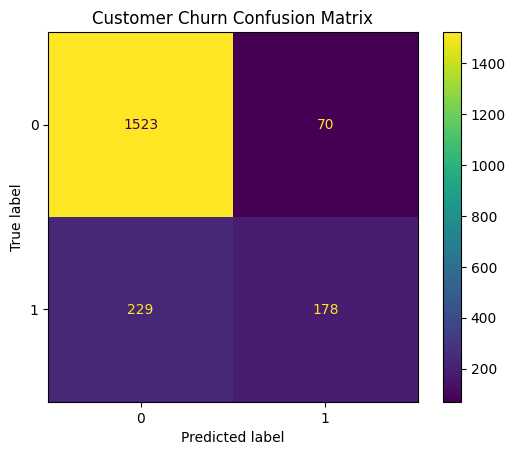

ROC-AUC: 0.8502755451907994


In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Customer Churn Confusion Matrix")
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# 22. Training and Validation Loss

### Good behavior
Both training and validation loss decrease.

### Overfitting
Training loss continues decreasing while validation loss stops improving or increases.

This is why validation curves are important.

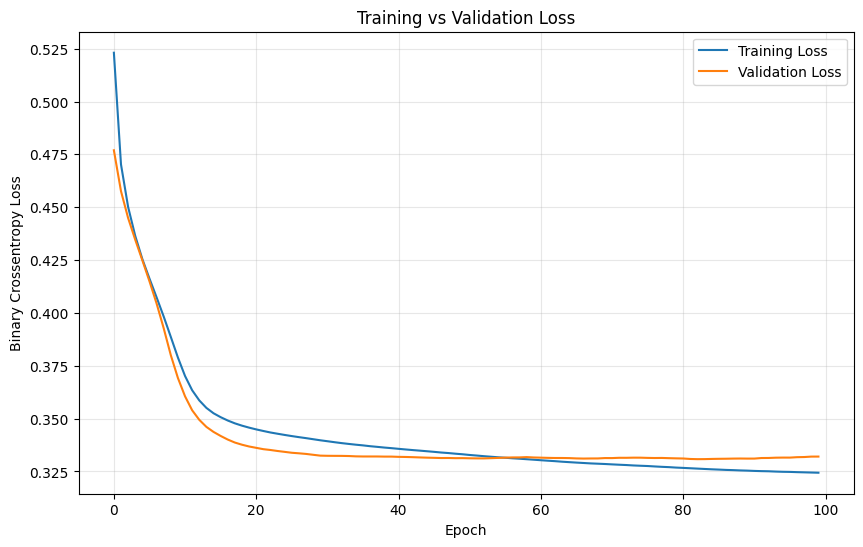

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 23. Training and Validation Accuracy

Compare training and validation accuracy.

A very large gap may indicate overfitting.

Important: high accuracy does not automatically mean a good churn model. Recall and precision may matter more depending on the business goal.

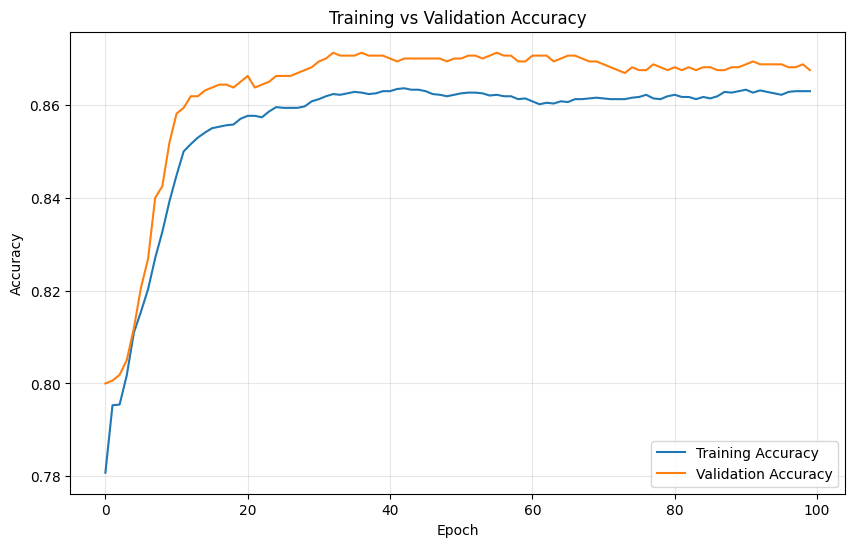

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 24. Improved Model – Dropout + Batch Normalization

### Dropout
Randomly deactivates some neurons during training.

Purpose: reduce overfitting.

### Batch Normalization
Normalizes intermediate activations.

Purpose: can improve training stability and gradient flow.

These techniques solve different problems and are not always required. Compare models experimentally.

In [23]:
improved_model = Sequential([
    Input(shape=(n_features,)),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.30),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.20),

    Dense(1, activation='sigmoid')
])

improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 96 (384.00 B)

# 25. Early Stopping

Training for more epochs does not always improve the model.

`EarlyStopping` monitors validation loss.

If validation performance does not improve for several epochs, training stops.

`restore_best_weights=True` restores the best model found during training.

In [24]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("Actual epochs trained:", len(improved_history.history['loss']))

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6762 - auc: 0.6268 - loss: 0.6495 - precision: 0.3044 - recall: 0.4527 - val_accuracy: 0.8188 - val_auc: 0.7574 - val_loss: 0.4457 - val_precision: 0.6364 - val_recall: 0.2188
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7875 - auc: 0.7015 - loss: 0.4944 - precision: 0.4738 - recall: 0.3450 - val_accuracy: 0.8263 - val_auc: 0.7852 - val_loss: 0.4159 - val_precision: 0.6981 - val_recall: 0.2313
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8084 - auc: 0.7251 - loss: 0.4599 - precision: 0.5633 - recall: 0.2855 - val_accuracy: 0.8306 - val_auc: 0.8029 - val_loss: 0.4037 - val_precision: 0.7168 - val_recall: 0.2531
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8094 - auc: 0.7460 - loss: 0.4447 - precision: 0.5701 - recall: 0.2794 - val_accuracy: 0.8375 - val_auc: 0.8203 - val_loss: 0.3871 - val_precision: 0.7679 - val_recall: 0.2688
Epoch 5/200
200/200 ━━━━━━━━

# 26. Compare Baseline and Improved Model

This experiment helps answer:

**Did additional architecture and regularization actually improve performance?**

Never assume a more complex neural network is automatically better.

In [25]:
baseline_results = model.evaluate(X_test_scaled, y_test, verbose=0, return_dict=True)
improved_results = improved_model.evaluate(X_test_scaled, y_test, verbose=0, return_dict=True)

comparison = pd.DataFrame({
    'Baseline': baseline_results,
    'Improved': improved_results
}).T

display(comparison.round(4))

,accuracy,loss,precision,recall,auc
Baseline,0.8505,0.3502,0.7177,0.4373,NaN
Improved,0.8630,0.3395,0.8065,0.4300,0.858


# 27. Threshold Experiment

For churn prediction, missing a customer who will leave may be expensive.

A lower threshold can increase recall but may also increase false positives.

This demonstrates the business trade-off between:
- Precision
- Recall

In [26]:
improved_prob = improved_model.predict(X_test_scaled, verbose=0).ravel()

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (improved_prob >= threshold).astype(int)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    print(
        f"Threshold={threshold} | "
        f"Precision={report['1']['precision']:.3f} | "
        f"Recall={report['1']['recall']:.3f} | "
        f"F1={report['1']['f1-score']:.3f}"
    )

Threshold=0.3 | Precision=0.617 | Recall=0.622 | F1=0.619
Threshold=0.4 | Precision=0.700 | Recall=0.538 | F1=0.608
Threshold=0.5 | Precision=0.806 | Recall=0.430 | F1=0.561
Threshold=0.6 | Precision=0.876 | Recall=0.329 | F1=0.479
Threshold=0.7 | Precision=0.902 | Recall=0.270 | F1=0.416


# 28. Hyperparameter Experiment Template

Try changing:

- Neurons: `8, 16, 32, 64`
- Layers: `1, 2, 3`
- Learning rate: `0.01, 0.001, 0.0001`
- Batch size: `16, 32, 64`
- Optimizer: `Adam, SGD`
- Dropout: `0.1, 0.2, 0.3`

This is how practical Deep Learning experimentation works.

In [27]:
def create_experiment_model(
    units1=32,
    units2=16,
    learning_rate=0.001,
    dropout_rate=0.2
):
    experiment_model = Sequential([
        Input(shape=(n_features,)),
        Dense(units1, activation='relu'),
        Dropout(dropout_rate),
        Dense(units2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    experiment_model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return experiment_model

experiment_model = create_experiment_model()
experiment_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

# 29. Final End-to-End Summary

## Data Level
1. Load dataset
2. Inspect structure
3. Check missing values and duplicates
4. Explore churn scenario
5. Remove identifiers
6. Encode categories
7. Split train/test
8. Scale features

## Neural Network Level
9. Define input
10. Add hidden layers
11. Select activation functions
12. Define output layer

## Training Level
13. Select loss
14. Select optimizer
15. Choose learning rate
16. Choose batch size
17. Choose epochs
18. Perform forward propagation
19. Calculate loss
20. Backpropagate gradients
21. Update weights

## Evaluation Level
22. Predict probabilities
23. Apply threshold
24. Evaluate accuracy, precision and recall
25. Analyze confusion matrix
26. Check overfitting curves

## Improvement Level
27. Add Dropout
28. Add Batch Normalization
29. Use Early Stopping
30. Tune hyperparameters

# Practice Questions

### Q1. Why is `sigmoid` used in the output layer?
Because this is binary classification and sigmoid produces probabilities between 0 and 1.

### Q2. Why do we scale data?
To make gradient-based training more stable when features have different numeric ranges.

### Q3. What is the difference between epoch and batch size?
An epoch is one complete pass through training data. A batch is the number of samples processed before one update.

### Q4. What does backpropagation do?
It calculates gradients showing how weights should change to reduce loss.

### Q5. Why is accuracy not enough for churn?
Because class imbalance can make a model appear accurate while missing many actual churners.

### Q6. Parameter vs hyperparameter?
Parameters are learned (weights and biases). Hyperparameters are chosen (learning rate, epochs, neurons, batch size).

### Recommended Next Step
Experiment with the architecture and create a comparison table of different hyperparameter combinations.